#Sección 0 — Portada y contexto

**Predicción de delitos de alto impacto utilizando datos abiertos del SESNSP**

Nombre del estudiante: **Octavio Quintero**

Matrícula: 266226

Fecha: 20 Mayo 2026


Dataset seleccionado

Se utilizará el dataset RNID Víctimas Estatal 2026, publicado por el Secretariado Ejecutivo del Sistema Nacional de Seguridad Pública (SESNSP).

Fuente oficial: https://www.gob.mx/sesnsp/acciones-y-programas/datos-abiertos-de-incidencia-delictiva

Pregunta de negocio

¿Es posible predecir si un registro corresponde a un delito de alto impacto utilizando variables demográficas y características del delito?

Objetivo

Desarrollar un modelo de machine learning capaz de clasificar registros de delitos en dos categorías:

Delito de alto impacto
Delito de bajo impacto

El propósito es identificar patrones relevantes que puedan apoyar procesos de análisis de seguridad pública.

Tipo de problema

Clasificación binaria.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    f1_score
)

In [ ]:
# Cargar dataset

df = pd.read_csv("/content/drive/MyDrive/Maestria/RNID-Víctimas_Estatal-2026-abr2026.csv", encoding='latin-1')

# Mostrar primeras filas

df.head()

,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Sexo,Rango de edad,Enero,...,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,2026,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,Hombre,0 a 12 años,0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,Hombre,13 a 17 años,0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,Hombre,18 a 29 años,0,...,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,Hombre,30 a 60 años,1,...,0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,Hombre,Más de 60 años,0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#Sección 1 — Exploración inicial (EDA)
Descripción inicial del dataset

En esta sección se realizará una exploración inicial de los datos con el objetivo de comprender su estructura, identificar posibles problemas de calidad y detectar patrones relevantes.

In [ ]:
# Dimensiones del dataset

df.shape

(65664, 21)

In [ ]:
# Tipos de datos

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65664 entries, 0 to 65663
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Año                     65664 non-null  int64  
 1   Clave_Ent               65664 non-null  int64  
 2   Entidad                 65664 non-null  object 
 3   Bien jurídico afectado  65664 non-null  object 
 4   Tipo de delito          65664 non-null  object 
 5   Subtipo de delito       65664 non-null  object 
 6   Modalidad               65664 non-null  object 
 7   Sexo                    65664 non-null  object 
 8   Rango de edad           65664 non-null  object 
 9   Enero                   65664 non-null  int64  
 10  Febrero                 65664 non-null  int64  
 11  Marzo                   65664 non-null  int64  
 12  Abril                   65664 non-null  int64  
 13  Mayo                    0 non-null      float64
 14  Junio                   0 non-null    

In [ ]:
# Estadísticos descriptivos

df.describe(include='all')

,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Sexo,Rango de edad,Enero,...,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
count,65664.0,65664.000000,65664,65664,65664,65664,65664,65664,65664,65664.000000,...,65664.000000,65664.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
unique,NaN,NaN,32,7,47,79,63,3,6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Aguascalientes,El patrimonio,Robo,Homicidio culposo,Con violencia,Hombre,0 a 12 años,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,2052,25920,20736,2880,10368,21888,10944,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2026.0,16.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.549784,...,2.895772,2.820434,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.0,9.233163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.417397,...,29.875808,34.825151,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2026.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2026.0,8.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2026.0,16.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2026.0,24.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Creación de variable objetivo**

Para transformar el problema en una tarea de clasificación binaria, se construirá la variable objetivo denominada Alto_Impacto.

Se considerarán delitos de alto impacto:

* Homicidio
* Feminicidio
* Secuestro
* Extorsión

In [ ]:
# Revisaremos nombres únicos de delitos

df['Tipo de delito'].unique()

array(['Homicidio',
       'Otros delitos que atentan contra la vida y la integridad corporal',
       'Lesiones', 'Feminicidio', 'Aborto',
       'Otros delitos que atentan contra la libertad personal',
       'Secuestro', 'Tráfico de menores', 'Rapto',
       'Privación ilegal de la libertad',
       'Retención o sustracción de menores e incapaces', 'Abuso sexual',
       'Otros delitos que atentan contra la libertad y la seguridad sexual',
       'Acoso sexual', 'Hostigamiento sexual', 'Incesto', 'Violación',
       'Violación a la intimidad sexual',
       'Otros delitos contra el patrimonio', 'Robo', 'Fraude',
       'Abuso de confianza', 'Extorsión', 'Daño a la propiedad',
       'Despojo', 'Otros delitos contra la familia', 'Violencia familiar',
       'Violencia de género en todas sus modalidades distinta a la violencia familiar',
       'Incumplimiento de obligaciones de asistencia familiar',
       'Corrupción de menores', 'Otros delitos contra la sociedad',
       'Trata de 

In [ ]:
#Clasificacion de alto impacto
alto_impacto = [
    'Homicidio',
    'Feminicidio',
    'Secuestro',
    'Extorsión'
]

In [ ]:
df['Alto_Impacto'] = df['Tipo de delito'].isin(alto_impacto).astype(int)

**Distribución de la variable objetivo**

La distribución de clases permite identificar si existe desbalance en el dataset.

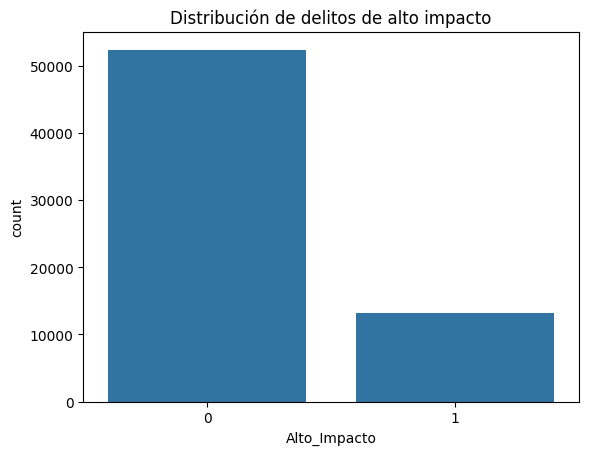

In [ ]:
sns.countplot(data=df, x='Alto_Impacto')
plt.title('Distribución de delitos de alto impacto')
plt.show()

Es posible observar un desbalance entre las clases, ya que los delitos de bajo impacto son considerablemente más frecuentes.

El dataset utilizado contiene registros agregados mensuales y no observaciones individuales. Por esta razón, las visualizaciones descriptivas deben utilizar el número total de víctimas y no únicamente el conteo de filas.

In [ ]:
meses = [
    'Enero',
    'Febrero',
    'Marzo',
    'Abril'
]

df['Total_Victimas'] = df[meses].sum(axis=1)

**Visualización 1 — Víctimas por sexo**

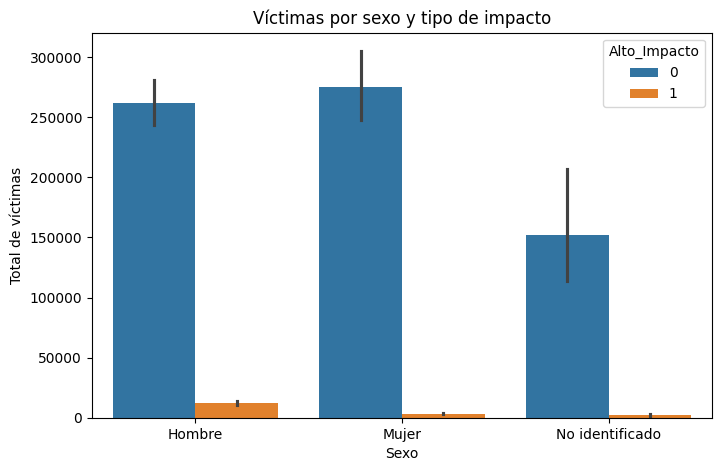

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Sexo',
    y='Total_Victimas',
    hue='Alto_Impacto',
    estimator=sum
)

plt.title('Víctimas por sexo y tipo de impacto')
plt.ylabel('Total de víctimas')
plt.show()

**Visualización 2 — Víctimas por rango de edad**

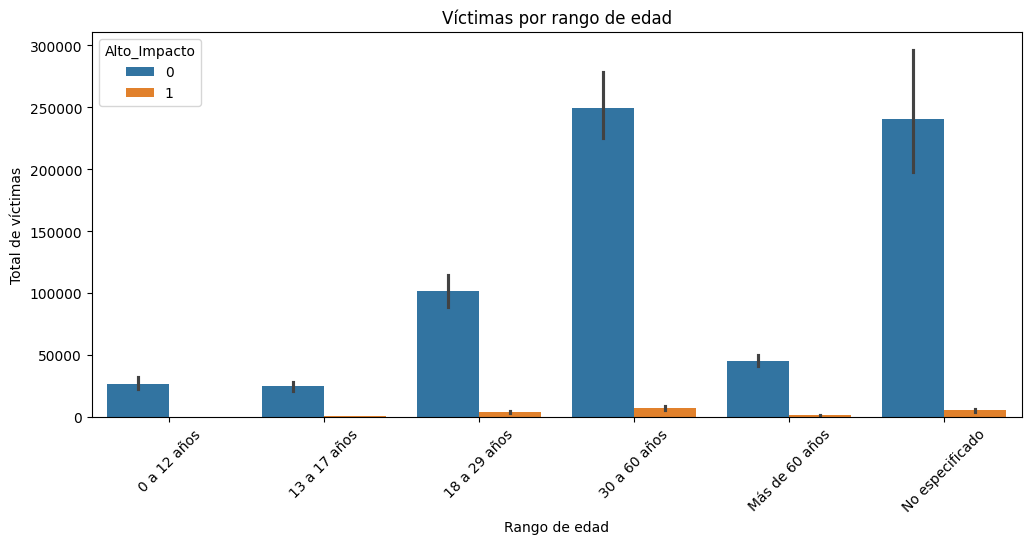

In [ ]:
plt.figure(figsize=(12,5))
sns.barplot(
    data=df,
    x='Rango de edad',
    y='Total_Victimas',
    hue='Alto_Impacto',
    estimator=sum
)

plt.xticks(rotation=45)
plt.title('Víctimas por rango de edad')
plt.ylabel('Total de víctimas')
plt.show()

**Visualización 3 — Distribución por entidad federativa**

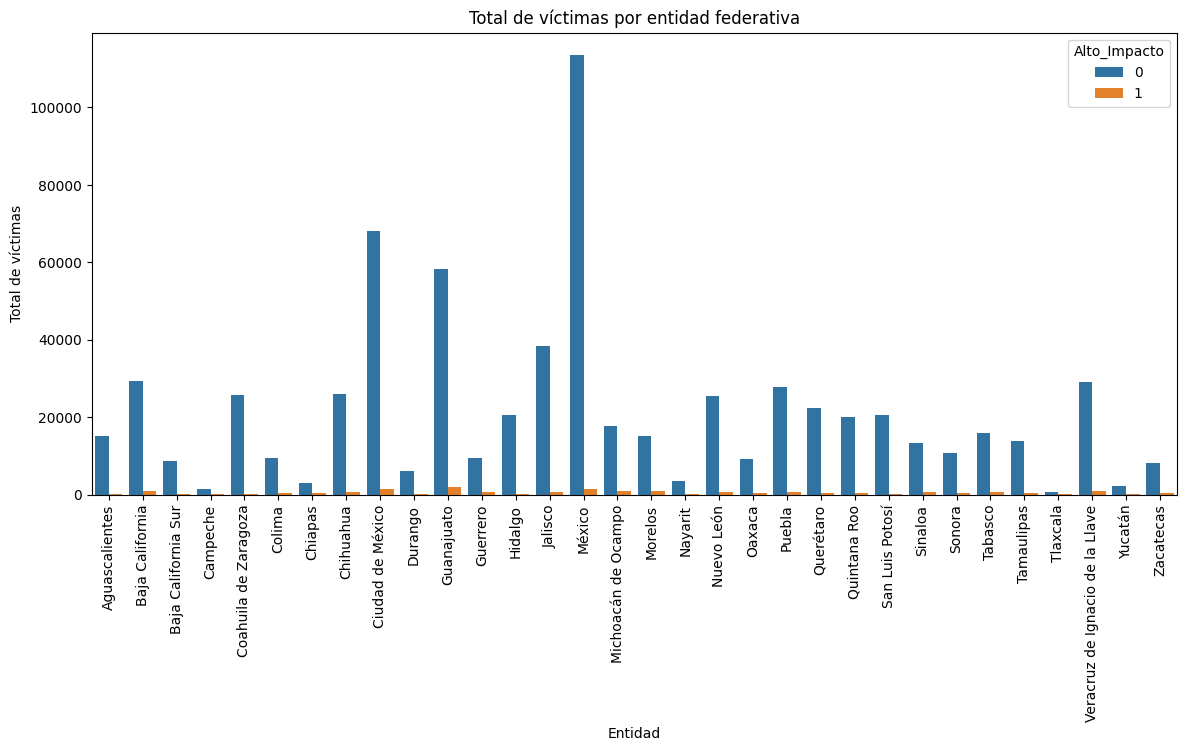

In [ ]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=df,
    x='Entidad',
    y='Total_Victimas',
    hue='Alto_Impacto',
    estimator=sum,
    errorbar=None
)

plt.xticks(rotation=90)
plt.title('Total de víctimas por entidad federativa')
plt.ylabel('Total de víctimas')
plt.show()

In [ ]:
# Valores faltantes

df.isnull().sum()

,0
Año,0
Clave_Ent,0
Entidad,0
Bien jurídico afectado,0
Tipo de delito,0
Subtipo de delito,0
Modalidad,0
Sexo,0
Rango de edad,0
Enero,0


#**Conclusion EDA**

Durante el análisis exploratorio se identificaron los siguientes aspectos:

* Existencia de variables categóricas.
* Posible desbalance de clases.
* Presencia de valores faltantes.
* Diferencias importantes entre entidades, edades y sexo.

**Para resolver estos problemas se implementará:**
* Codificación OneHotEncoder para variables categóricas.
* Escalado de variables numéricas.
* Validación estratificada para preservar la distribución de clases.
* Uso de pipelines para evitar data leakage.

#Sección 2 — Preprocesamiento

Selección de variables

In [ ]:
# Variables predictoras

X = df[[
    'Entidad',
    'Sexo',
    'Rango de edad',
    'Bien jurídico afectado'
]]

# Variable objetivo

y = df['Alto_Impacto']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # La estratificación es importante debido al desbalance de clases identificado durante el EDA.
)

In [ ]:
categorical_features = X.select_dtypes(include='object').columns
numeric_features = X.select_dtypes(exclude='object').columns

categorical_features

Index(['Entidad', 'Sexo', 'Rango de edad', 'Bien jurídico afectado'], dtype='object')

In [ ]:
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Las transformaciones se ajustarán únicamente sobre el conjunto de entrenamiento para evitar data leakage.

* Se utiliza imputación por mediana para variables numéricas debido a su robustez frente a valores extremos.
* Se utiliza imputación por moda en variables categóricas.
* OneHotEncoder permite transformar variables categóricas en representaciones numéricas.
* StandardScaler se utiliza para normalizar escalas y favorecer modelos sensibles a magnitudes como Logistic Regression.

#Sección 3 — Modelos y justificación

Modelo 1 — Logistic Regression

Se selecciona Logistic Regression como modelo base debido a su interpretabilidad y eficiencia en problemas de clasificacion binaria.

In [ ]:
logistic_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ]
)
logistic_pipeline.fit(X_train, y_train)

# Predicciones
y_pred_log = logistic_pipeline.predict(X_test)
y_prob_log = logistic_pipeline.predict_proba(X_test)[:,1]
#metricas
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.91      0.88      0.90     10483
           1       0.58      0.66      0.62      2650

    accuracy                           0.84     13133
   macro avg       0.75      0.77      0.76     13133
weighted avg       0.84      0.84      0.84     13133



#Modelo 2 — Random Forest

Random Forest fue seleccionado debido a su capacidad para modelar relaciones no lineales y manejar interacciones complejas entre variables.



In [ ]:
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ]
)

rf_pipeline.fit(X_train, y_train)

# Predicciones

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.86      0.87     10483
           1       0.50      0.57      0.53      2650

    accuracy                           0.80     13133
   macro avg       0.69      0.71      0.70     13133
weighted avg       0.81      0.80      0.80     13133



#Comparacion de modelos

In [ ]:
results_base = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Random Forest'],
    'F1-score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results_base

,Modelo,F1-score,ROC-AUC
0,Logistic Regression,0.619124,0.861753
1,Random Forest,0.532484,0.817631


#Sección 4 — Optimización de hiperparámetros

Validación cruzada

Se utilizará StratifiedKFold con 5 particiones para preservar la distribución de clases durante la validación.

In [ ]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Optimización Logistic Regression

In [ ]:
param_grid_log = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs']
}

In [ ]:
grid_log = GridSearchCV(
    logistic_pipeline,
    param_grid=param_grid_log,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1
)

In [ ]:
grid_log.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index([], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['Entidad', 'Sexo', 'Rango de edad', 'Bien jurídico afectado'], dtype='object'))])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__penalty': ['l2'],
                         'classifier__solver': ['lbfgs']},
             scoring='f1')

In [ ]:
print('Mejores parametros:')
print(grid_log.best_params_)

print('\nMejor F1-score promedio en validacion cruzada:')
print(grid_log.best_score_)

Mejores parametros:
{'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Mejor F1-score promedio en validacion cruzada:
0.6105215105170899


In [ ]:
best_log = grid_log.best_estimator_

#Optimización Random Forest

In [ ]:
param_grid_rf = {
    'classifier__n_estimators': [50],
    'classifier__max_depth': [5, 10],
    'classifier__min_samples_split': [2, 5]
}

In [ ]:
grid_rf = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid_rf,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1
)

In [ ]:
grid_rf.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index([], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['Entidad', 'Sexo', 'Rango de edad', 'Bien jurídico afectado'], dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [50]},
             scoring='f1')

In [ ]:
print('Mejores parametros encontrados:')
print(grid_rf.best_params_)

print('\nMejor F1-score promedio en validacion cruzada:')
print(grid_rf.best_score_)

Mejores parametros encontrados:
{'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}

Mejor F1-score promedio en validacion cruzada:
0.5519125294535405


In [ ]:
best_rf = grid_rf.best_estimator_

#Comparación entre modelos base y optimizados

El objetivo de esta sección es comparar el desempeño de los modelos antes y después de la optimización de hiperparámetros.

La comparación permitirá evaluar si la búsqueda de hiperparámetros produjo mejoras relevantes en la capacidad predictiva.

In [ ]:
# Predicciones optimizadas

y_pred_log_opt = best_log.predict(X_test)
y_prob_log_opt = best_log.predict_proba(X_test)[:,1]

y_pred_rf_opt = best_rf.predict(X_test)
y_prob_rf_opt = best_rf.predict_proba(X_test)[:,1]

In [ ]:
results_optimized = pd.DataFrame({
    'Modelo': [
        'Logistic Base',
        'Random Forest Base',
        'Logistic Optimizado',
        'Random Forest Optimizado'
    ],
    'F1-score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_log_opt),
        f1_score(y_test, y_pred_rf_opt)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_log_opt),
        roc_auc_score(y_test, y_prob_rf_opt)
    ]
})

results_optimized

,Modelo,F1-score,ROC-AUC
0,Logistic Base,0.619124,0.861753
1,Random Forest Base,0.532484,0.817631
2,Logistic Optimizado,0.619124,0.861970
3,Random Forest Optimizado,0.577860,0.851444


Los resultados muestran que Logistic Regression obtuvo el mejor desempeño general, alcanzando un F1-score de 0.619 y un ROC-AUC superior a 0.86.

Esto sugiere que el modelo posee una buena capacidad para distinguir entre delitos de alto y bajo impacto, aunque todavía existen limitaciones para equilibrar precisión y recall debido al desbalance de clases presente en el dataset.

Por otro lado, Random Forest mostró una mejora importante después de la optimización de hiperparámetros.

Finalmente, la mejora observada en Logistic Regression tras el tuning sugiere que el modelo base ya se encontraba cerca de una configuración adecuada para este problema.

# Seccion 6 — Conclusiones

## Respuesta a la pregunta de negocio

El objetivo del proyecto fue determinar si era posible predecir delitos de alto impacto utilizando variables demograficas y caracteristicas del delito.

Los resultados obtenidos muestran que si fue posible identificar patrones relevantes mediante modelos de machine learning. Logistic Regression obtuvo el mejor desempeño general, alcanzando un F1-score cercano a 0.62 y un ROC-AUC superior a 0.86, mostrando una buena capacidad para diferenciar entre delitos de alto y bajo impacto.

---

## Reflexion sobre el desempeño

El desempeño del modelo puede considerarse aceptable para este tipo de problema. El valor de ROC-AUC indica una buena capacidad de clasificacion, mientras que el F1-score muestra un equilibrio razonable entre precision y recall.

Ademas, los resultados obtenidos en validacion cruzada y en el conjunto de prueba fueron similares, lo que indica que el modelo generaliza de manera adecuada y no presenta un sobreajuste importante.

Sin embargo, el modelo aun no seria suficientemente confiable para utilizarse directamente en un entorno real relacionado con seguridad publica. Esto lo deduzco del resultado de F1.

---

## Limitaciones identificadas

El proyecto presenta algunas limitaciones importantes:

- Existe desbalance entre las clases.
- Los datos pueden contener sesgos o inconsistencias debido al proceso de registro.

Ademas, el desempeño del modelo aun puede mejorar, especialmente en la deteccion correcta de delitos de alto impacto.

---

## Propuestas de mejora

Con mas tiempo y recursos se podrian implementar mejoras como:

- Uso de tecnicas de balanceo como SMOTE.
- Incorporacion de datos historicos y temporales.
- Uso de modelos mas complejos.
- Incorporacion de variables socioeconomicas y geograficas.

---

## Conclusion general

En general, el proyecto permitio aplicar correctamente las principales etapas de un flujo de machine learning, incluyendo exploracion de datos, preprocesamiento, entrenamiento, optimizacion y evaluacion de modelos.

Tambien se aplicaron buenas practicas importantes como el uso de pipelines y validacion estratificada para evitar data leakage y mejorar la confiabilidad de los resultados.